# Análisis Exploratorio de Datos - Predicción de Precios de Casas

## Objetivo
Realizar un análisis exploratorio completo del conjunto de datos `train.csv` para comprender la estructura de los datos, identificar relaciones entre variables y determinar las transformaciones necesarias antes de construir modelos predictivos.

## Metodología
Se analizarán distribuciones univariadas, correlaciones bivariadas, relaciones entre variables independientes y la variable dependiente (precio), y se identificarán las transformaciones requeridas para la modelización.

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo para visualizaciones
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

## 1. Cargar y Explorar los Datos

En esta sección cargamos el archivo `train.csv` e inspeccionamos sus características principales como dimensiones, tipos de datos, valores faltantes y estadísticas descriptivas básicas.

In [ ]:
# Cargar el conjunto de datos
df = pd.read_csv(r'..\data\raw\train.csv')

# Mostrar información básica del dataset
print("=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 80)
print(f"\nDimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nPrimeras 5 filas del dataset:")

with pd.option_context('display.max_columns', None, 'display.width', None, 'display.max_colwidth', None):
    display(df.head(10))

NameError: name 'pd' is not defined

In [3]:
# Información detallada sobre tipos de datos y valores faltantes
print("\n" + "=" * 80)
print("TIPOS DE DATOS Y VALORES FALTANTES")
print("=" * 80)
print(df.info())

print("\n" + "-" * 80)
print("RESUMEN DE VALORES FALTANTES")
print("-" * 80)
missing_data = pd.DataFrame({
    'Columna': df.columns,
    'Valores_Faltantes': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Valores_Faltantes'] > 0].sort_values('Valores_Faltantes', ascending=False)
if len(missing_data) > 0:
    print(missing_data.to_string(index=False))
else:
    print("No hay valores faltantes en el dataset")


TIPOS DE DATOS Y VALORES FALTANTES


NameError: name 'df' is not defined

In [5]:
# Estadísticas descriptivas de variables numéricas
print("\n" + "=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("=" * 80)
df.describe().T


ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


## 2. Análisis Univariado de Variables

Analizamos la distribución individual de cada variable mediante histogramas, boxplots y estadísticas de resumen incluyendo asimetría (skewness) y curtosis.

In [6]:
# Separar variables numéricas y categóricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Variables Numéricas:", len(numeric_cols))
print(numeric_cols[:10], "..." if len(numeric_cols) > 10 else "")
print("\nVariables Categóricas:", len(categorical_cols))
print(categorical_cols)

Variables Numéricas: 38
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1'] ...

Variables Categóricas: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [7]:
# Calcular asimetría y curtosis para variables numéricas
print("\n" + "=" * 80)
print("ANÁLISIS DE FORMA DE DISTRIBUCIONES (ASIMETRÍA Y CURTOSIS)")
print("=" * 80)
shape_stats = pd.DataFrame({
    'Variable': numeric_cols,
    'Media': [df[col].mean() for col in numeric_cols],
    'Mediana': [df[col].median() for col in numeric_cols],
    'Desv.Est': [df[col].std() for col in numeric_cols],
    'Asimetría': [stats.skew(df[col].dropna()) for col in numeric_cols],
    'Curtosis': [stats.kurtosis(df[col].dropna()) for col in numeric_cols]
})
print(shape_stats.to_string(index=False))


ANÁLISIS DE FORMA DE DISTRIBUCIONES (ASIMETRÍA Y CURTOSIS)
     Variable         Media  Mediana     Desv.Est  Asimetría   Curtosis
           Id    730.500000    730.5   421.610009   0.000000  -1.200001
   MSSubClass     56.897260     50.0    42.300571   1.406210   1.570675
  LotFrontage     70.049958     69.0    24.284752   2.160866  17.375300
      LotArea  10516.828082   9478.5  9981.264932  12.195142 202.543793
  OverallQual      6.099315      6.0     1.382997   0.216721   0.091857
  OverallCond      5.575342      5.0     1.112799   0.692355   1.098521
    YearBuilt   1971.267808   1973.0    30.202904  -0.612831  -0.442155
 YearRemodAdd   1984.865753   1994.0    20.645407  -0.503044  -1.271999
   MasVnrArea    103.685262      0.0   181.066207   2.666326  10.043602
   BsmtFinSF1    443.639726    383.5   456.098091   1.683771  11.076090
   BsmtFinSF2     46.549315      0.0   161.319273   4.250888  20.040415
    BsmtUnfSF    567.240411    477.5   441.866955   0.919323   0.469262
  To

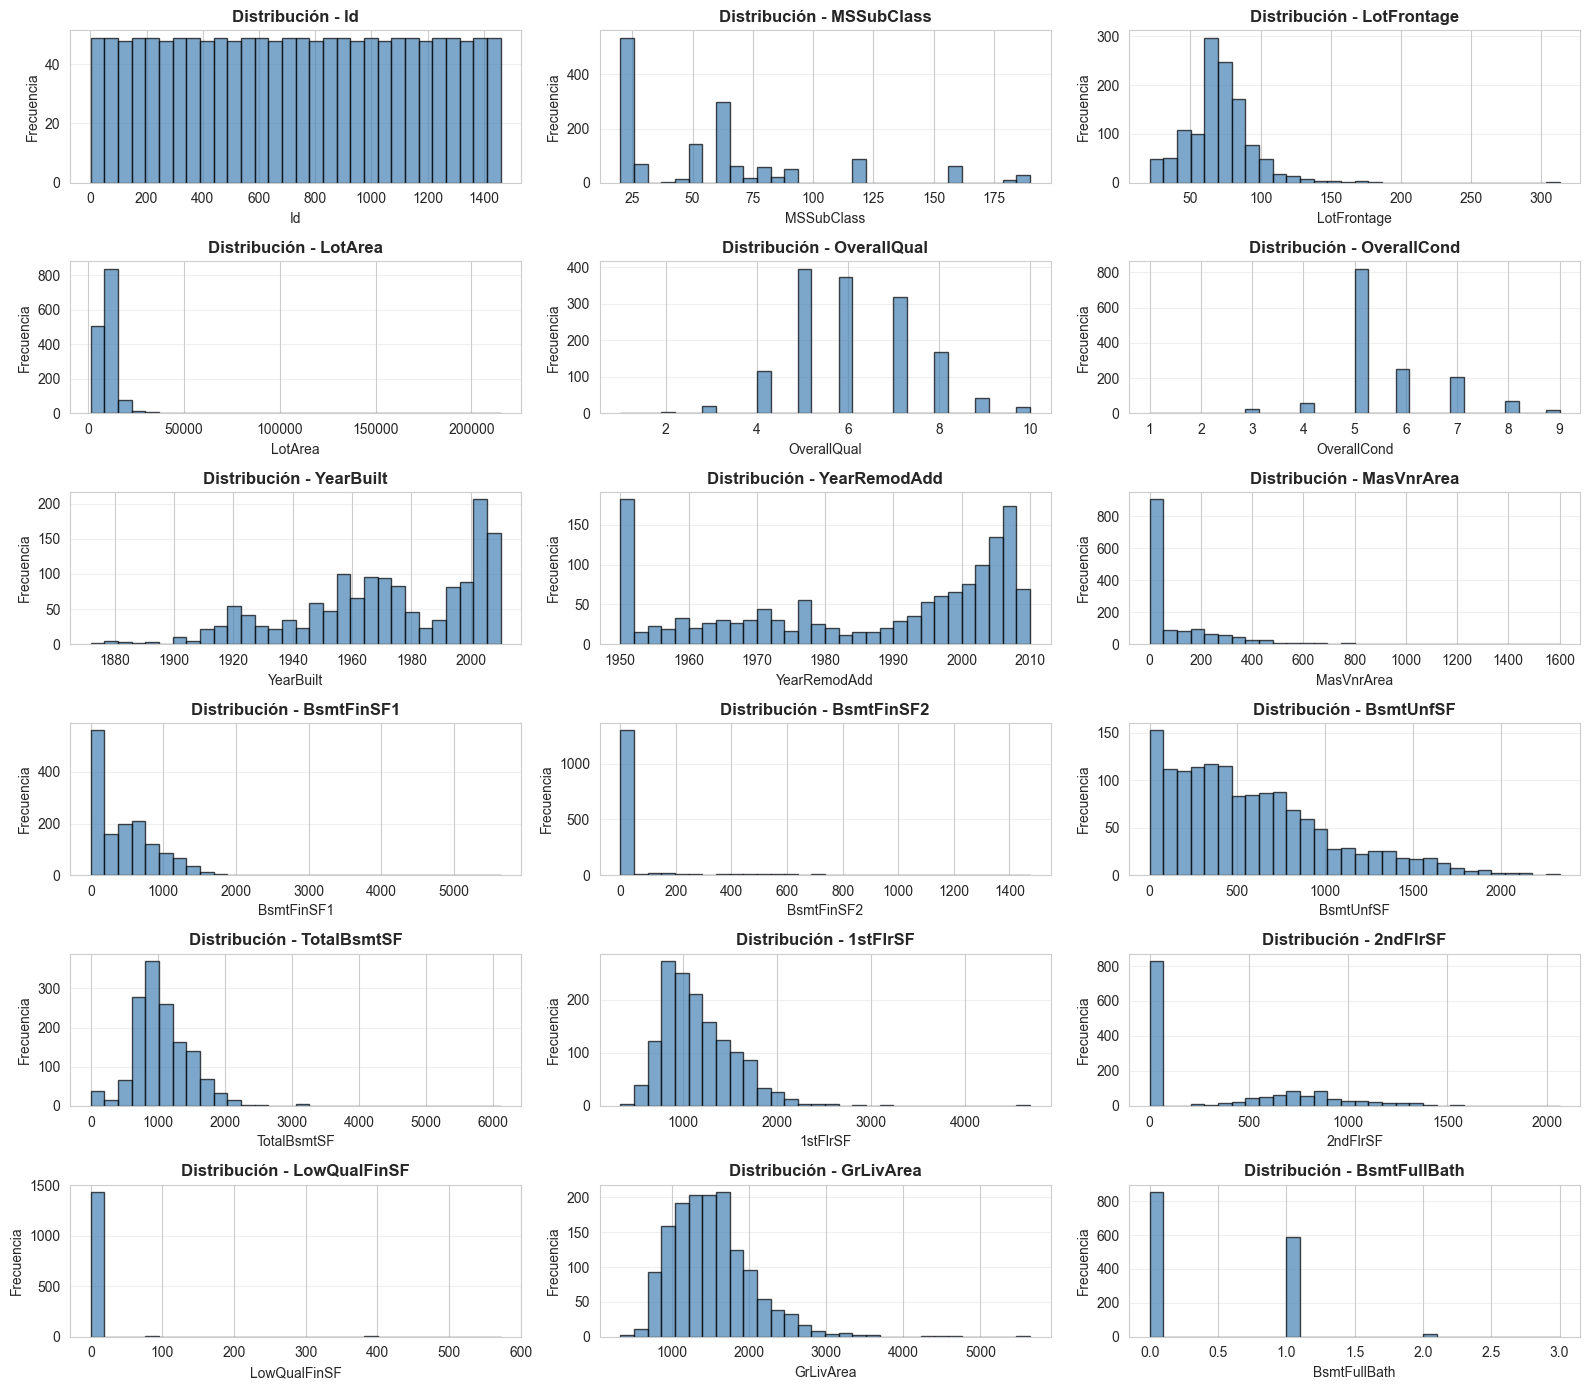

Histogramas de las primeras 18 variables numéricas


In [8]:
# Visualizar distribuciones de variables numéricas (primeras 15 variables)
fig, axes = plt.subplots(6, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:18]):
    axes[idx].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribución - {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Histogramas de las primeras 18 variables numéricas")

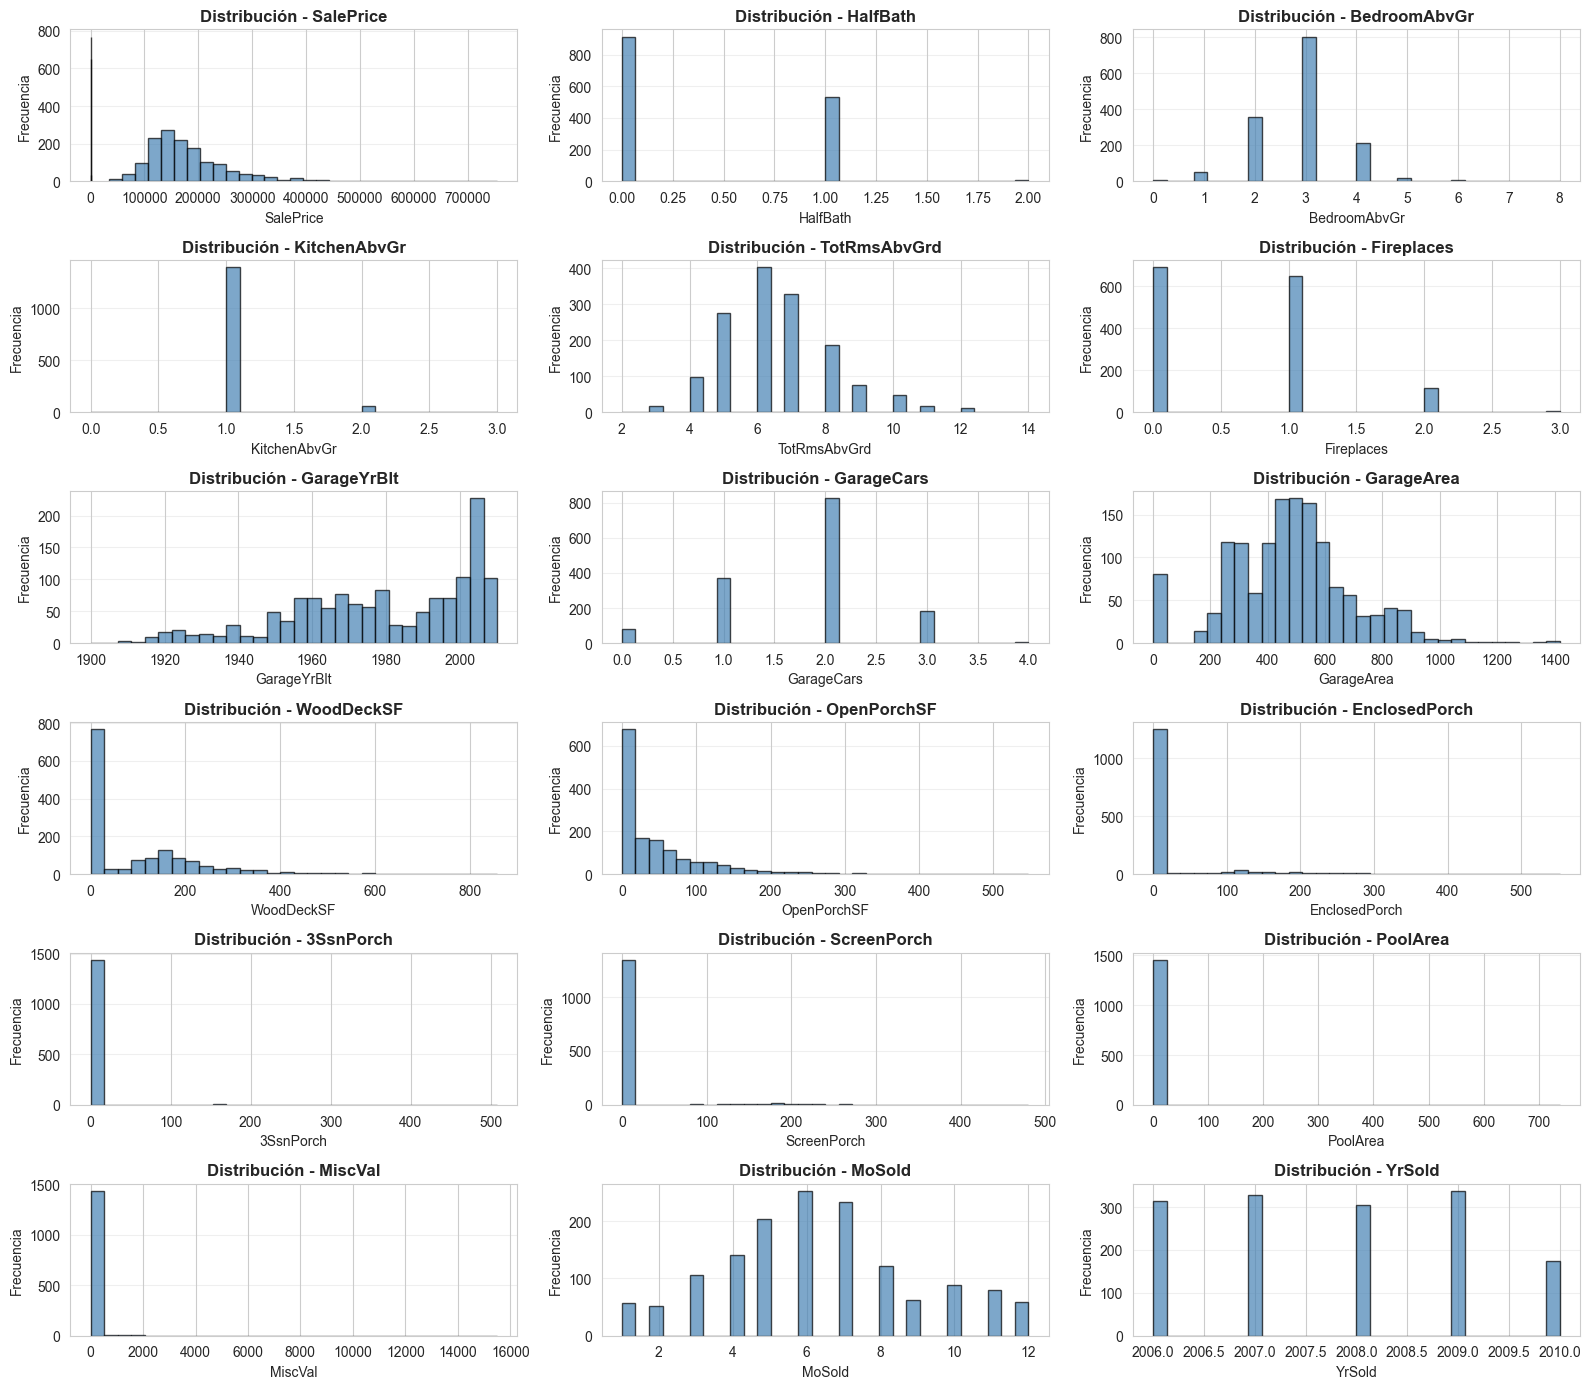

Histogramas de las otras 20 variables numéricas


In [9]:
# Visualizar distribuciones de variables numéricas (primeras 15 variables)
fig, axes = plt.subplots(6, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[19:38]):
    axes[idx-18].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx-18].set_title(f'Distribución - {col}', fontweight='bold')
    axes[idx-18].set_xlabel(col)
    axes[idx-18].set_ylabel('Frecuencia')
    axes[idx-18].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Histogramas de las otras 20 variables numéricas")

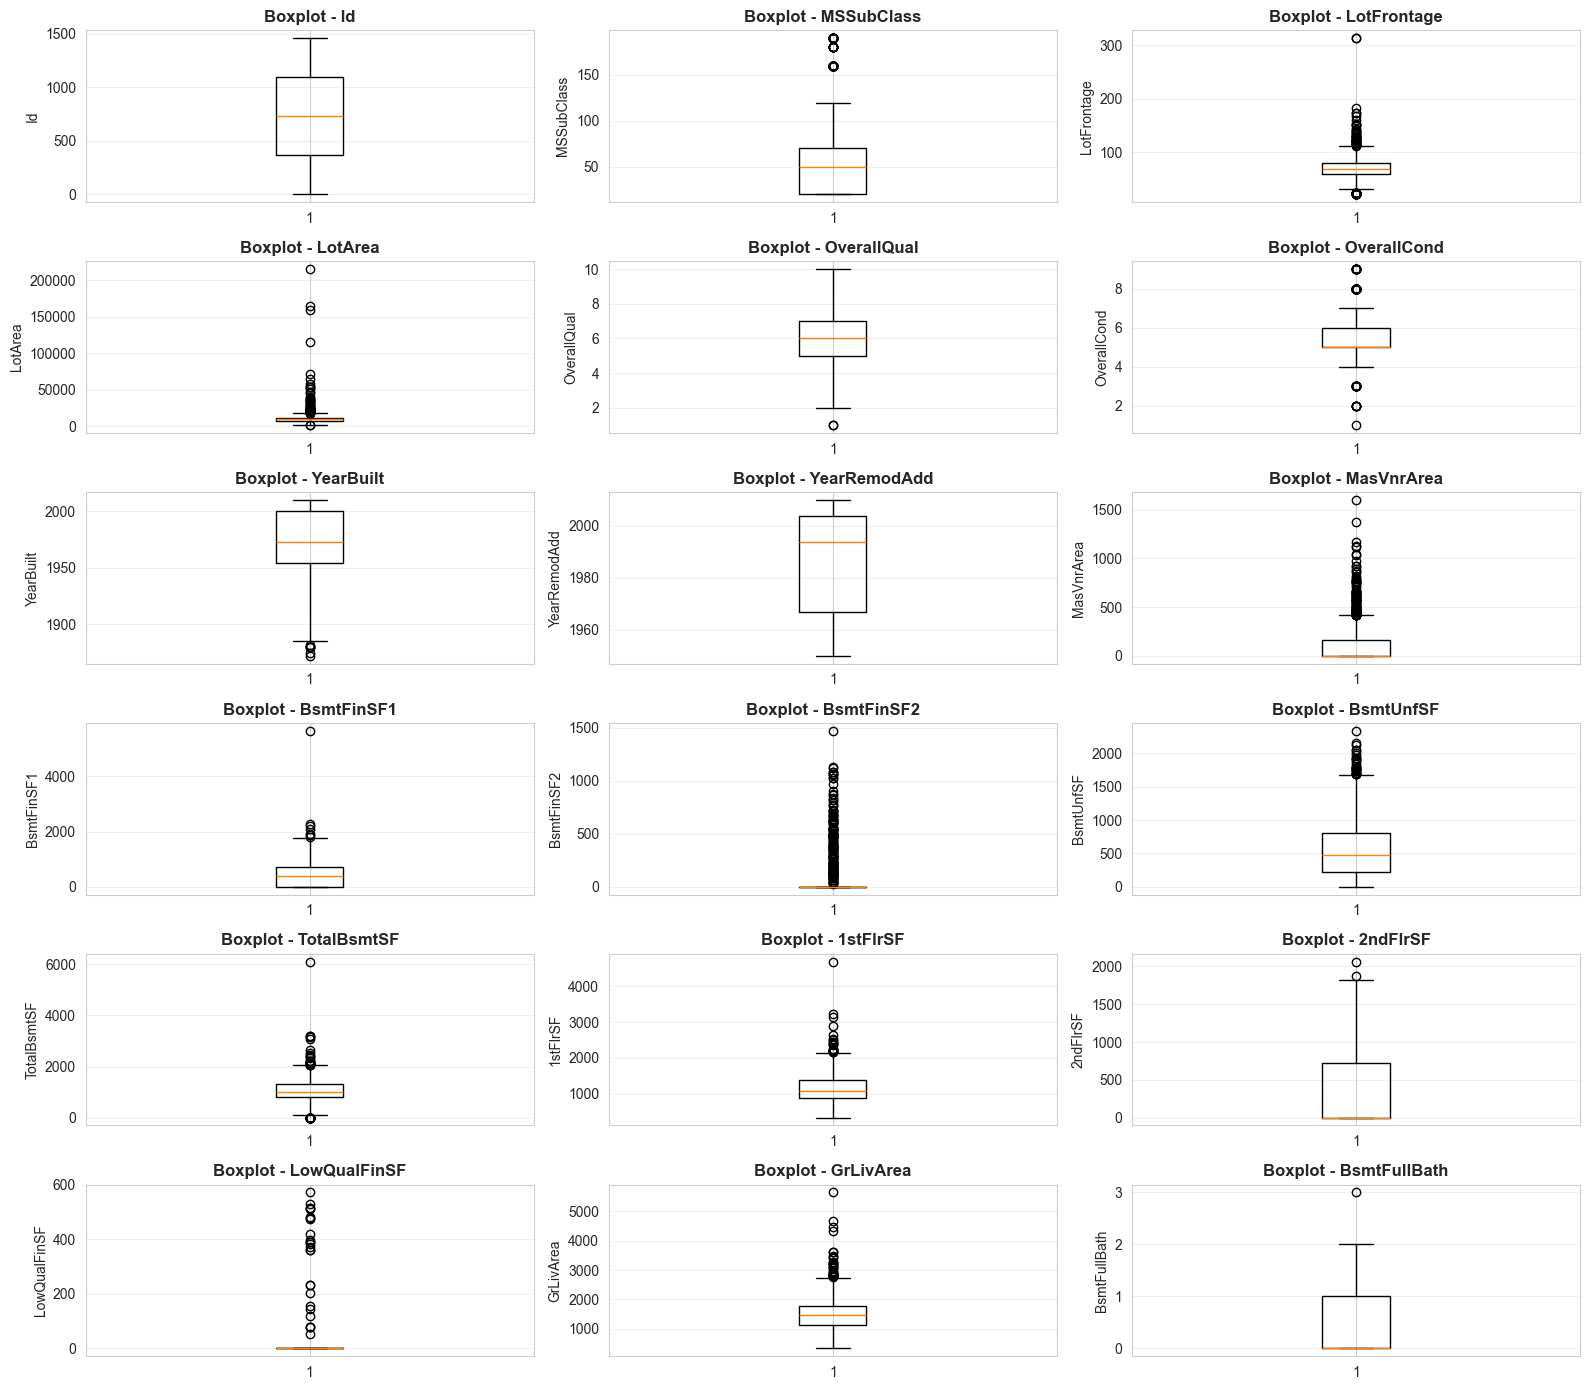

Boxplots de las primeras 18 variables numéricas (útiles para identificar outliers)


In [10]:
# Boxplots para detectar outliers en variables numéricas (primeras 18 variables)
fig, axes = plt.subplots(6, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:18]):
    axes[idx].boxplot(df[col].dropna(), vert=True)
    axes[idx].set_title(f'Boxplot - {col}', fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Boxplots de las primeras 18 variables numéricas (útiles para identificar outliers)")

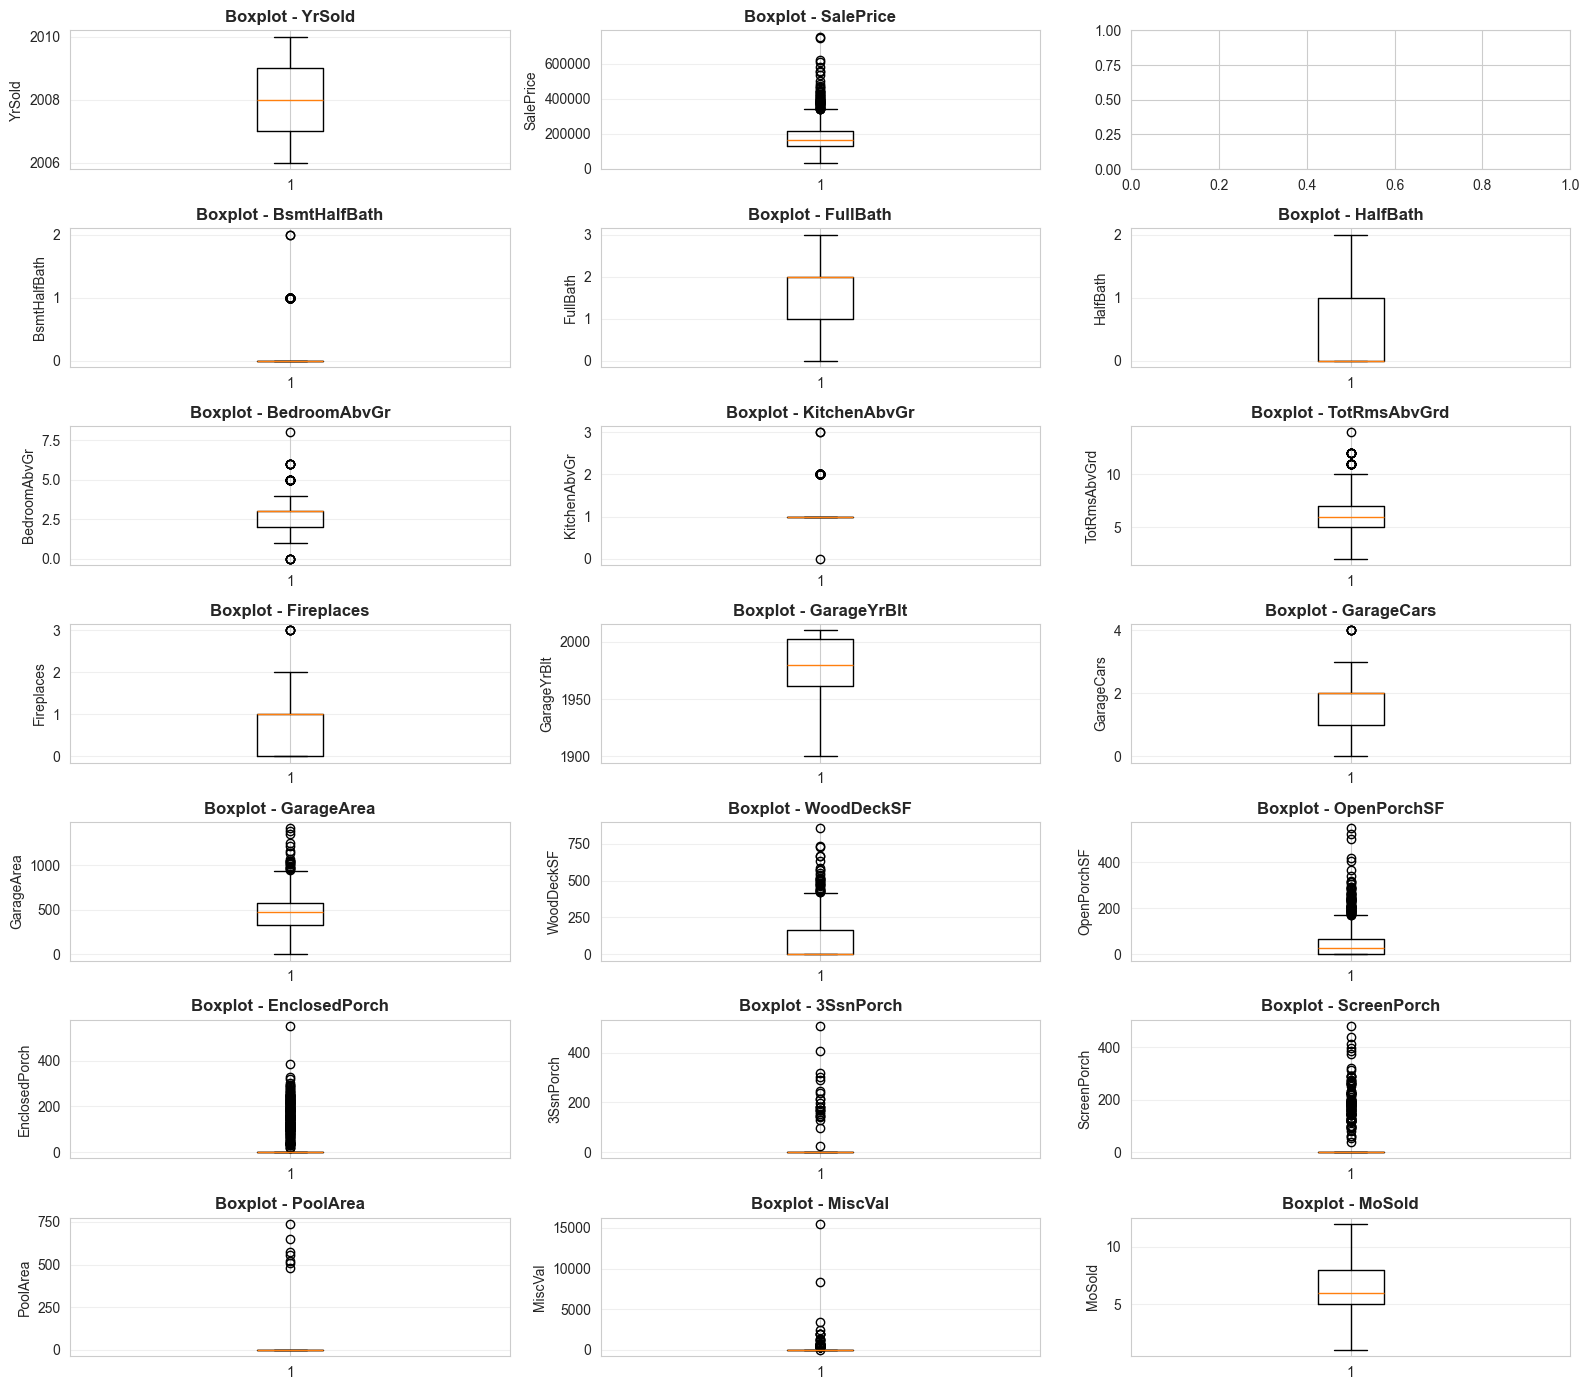

Boxplots de las otras 20 variables numéricas (útiles para identificar outliers)


In [11]:
# Boxplots para detectar outliers en variables numéricas (primeras 15 variables)
fig, axes = plt.subplots(7, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[18:38]):
    axes[idx-18].boxplot(df[col].dropna(), vert=True)
    axes[idx-18].set_title(f'Boxplot - {col}', fontweight='bold')
    axes[idx-18].set_ylabel(col)
    axes[idx-18].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Boxplots de las otras 20 variables numéricas (útiles para identificar outliers)")

## 3. Análisis de Correlaciones

Calculamos la matriz de correlación de Pearson entre todas las variables numéricas y visualizamos con un heatmap para identificar relaciones lineales, especialmente con la variable dependiente (precio/SalePrice).

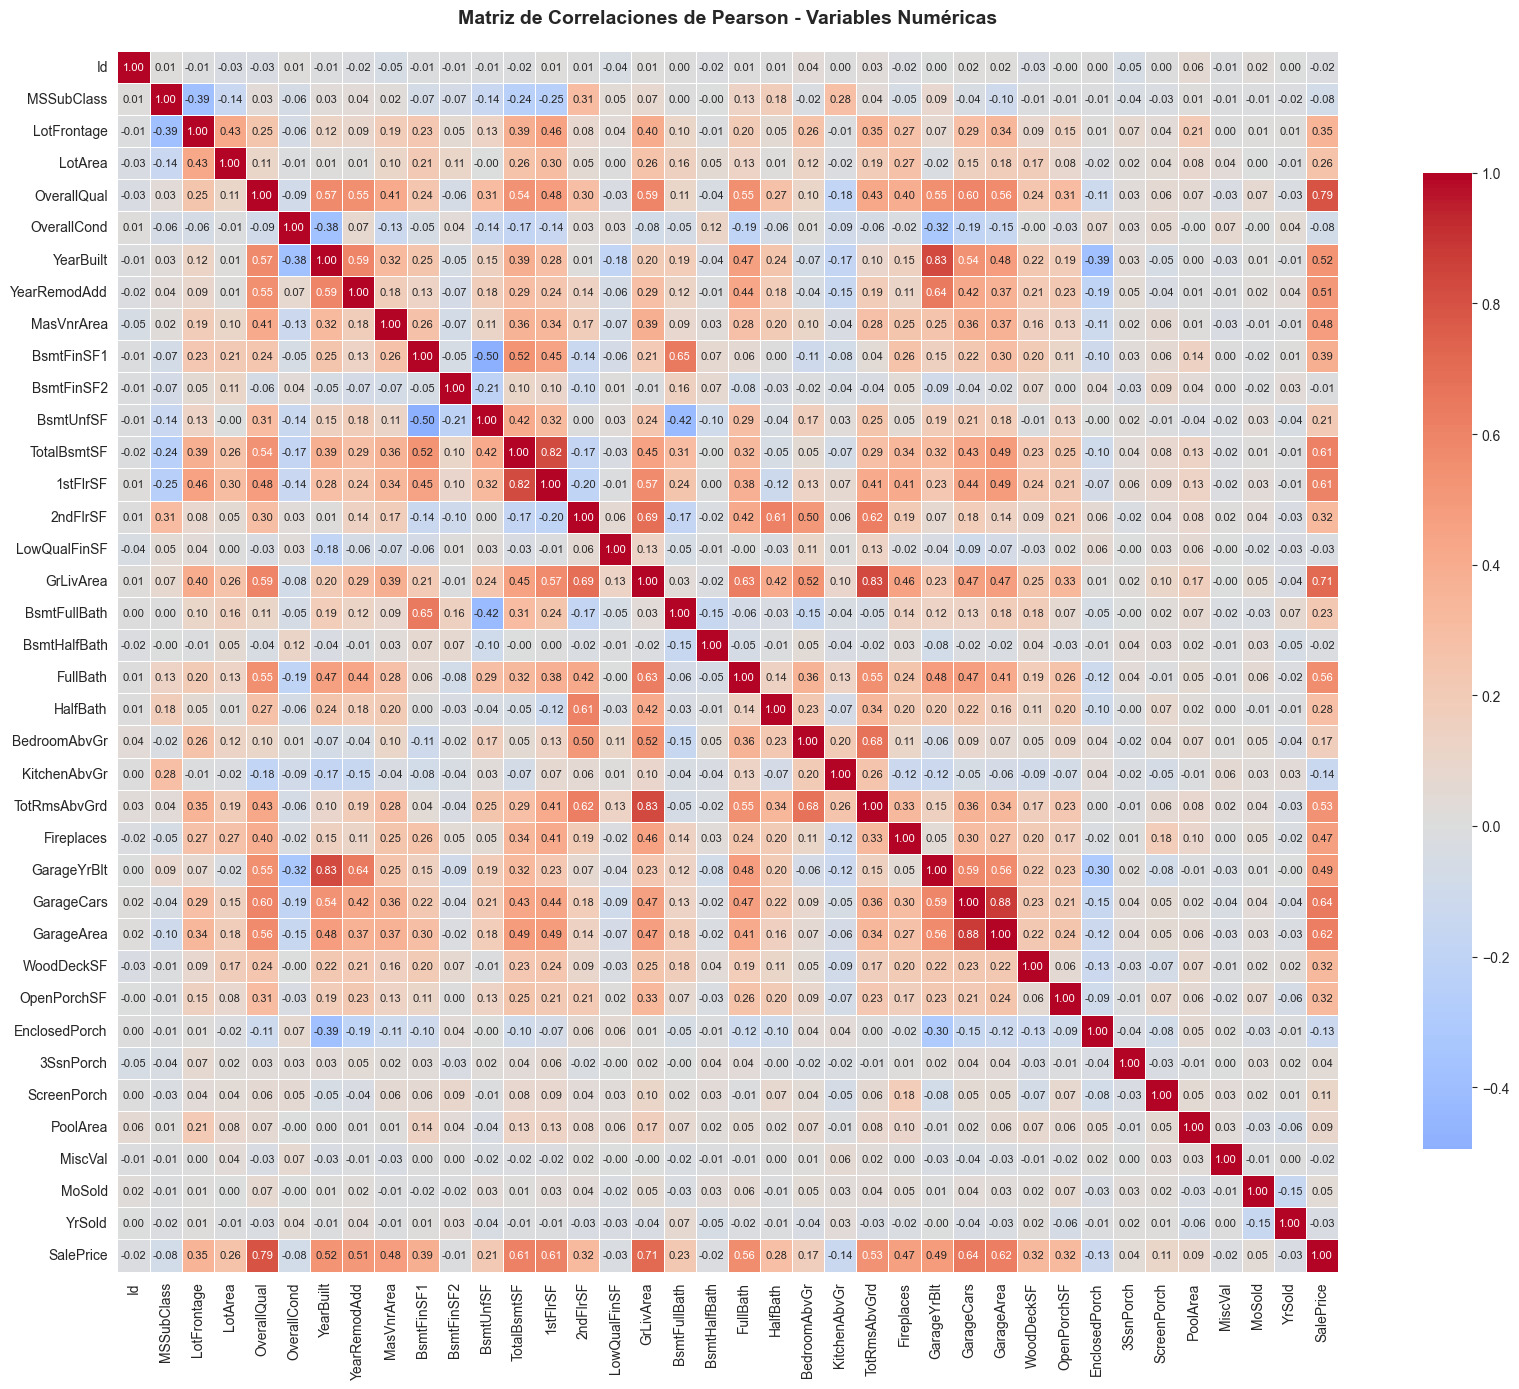

In [12]:
# Calcular matriz de correlación
correlation_matrix = df[numeric_cols].corr()

# Crear heatmap de correlaciones
plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, annot_kws={'size': 8})
plt.title('Matriz de Correlaciones de Pearson - Variables Numéricas', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [13]:
# Identificar correlaciones con la variable dependiente (asumiendo que existe SalePrice o Price)
# Buscar la columna de precio
target_cols = [col for col in numeric_cols if col.lower() in ['saleprice', 'price', 'target', 'y']]
if len(target_cols) == 0:
    # Si no existe, usar la última columna numérica como target
    target = numeric_cols[-1]
else:
    target = target_cols[0]

print("\n" + "=" * 80)
print(f"CORRELACIONES CON LA VARIABLE DEPENDIENTE: {target}")
print("=" * 80)
correlations_with_target = correlation_matrix[target].sort_values(ascending=False)
print(correlations_with_target)


CORRELACIONES CON LA VARIABLE DEPENDIENTE: SalePrice
SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPo

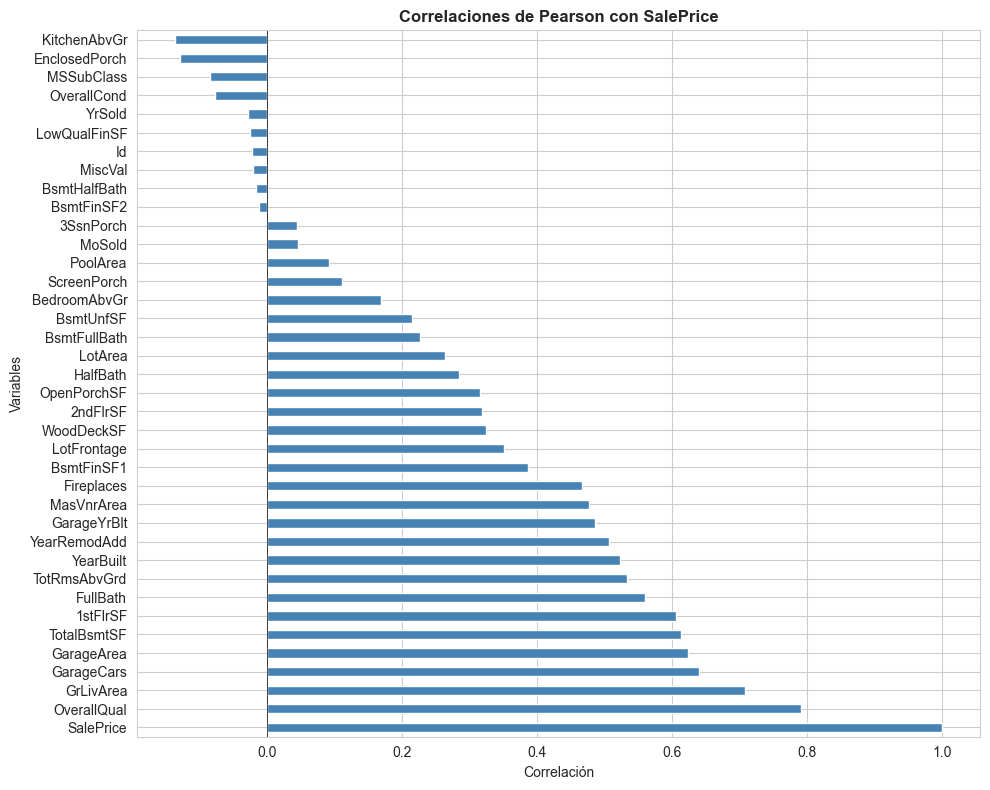


Variables con correlación > 0.5 (positiva o negativa):
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [14]:
# Visualizar correlaciones con la variable dependiente
plt.figure(figsize=(10, 8))
correlations_with_target.plot(kind='barh', color='steelblue')
plt.title(f'Correlaciones de Pearson con {target}', fontsize=12, fontweight='bold')
plt.xlabel('Correlación')
plt.ylabel('Variables')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"\nVariables con correlación > 0.5 (positiva o negativa):")
strong_corr = correlations_with_target[(abs(correlations_with_target) > 0.5) & (correlations_with_target.index != target)]
print(strong_corr)

## 4. Distribuciones de Variables Independientes vs Dependiente

Creamos gráficos scatter y análisis de dispersión entre cada variable independiente y la variable dependiente para evaluar relaciones y patrones.

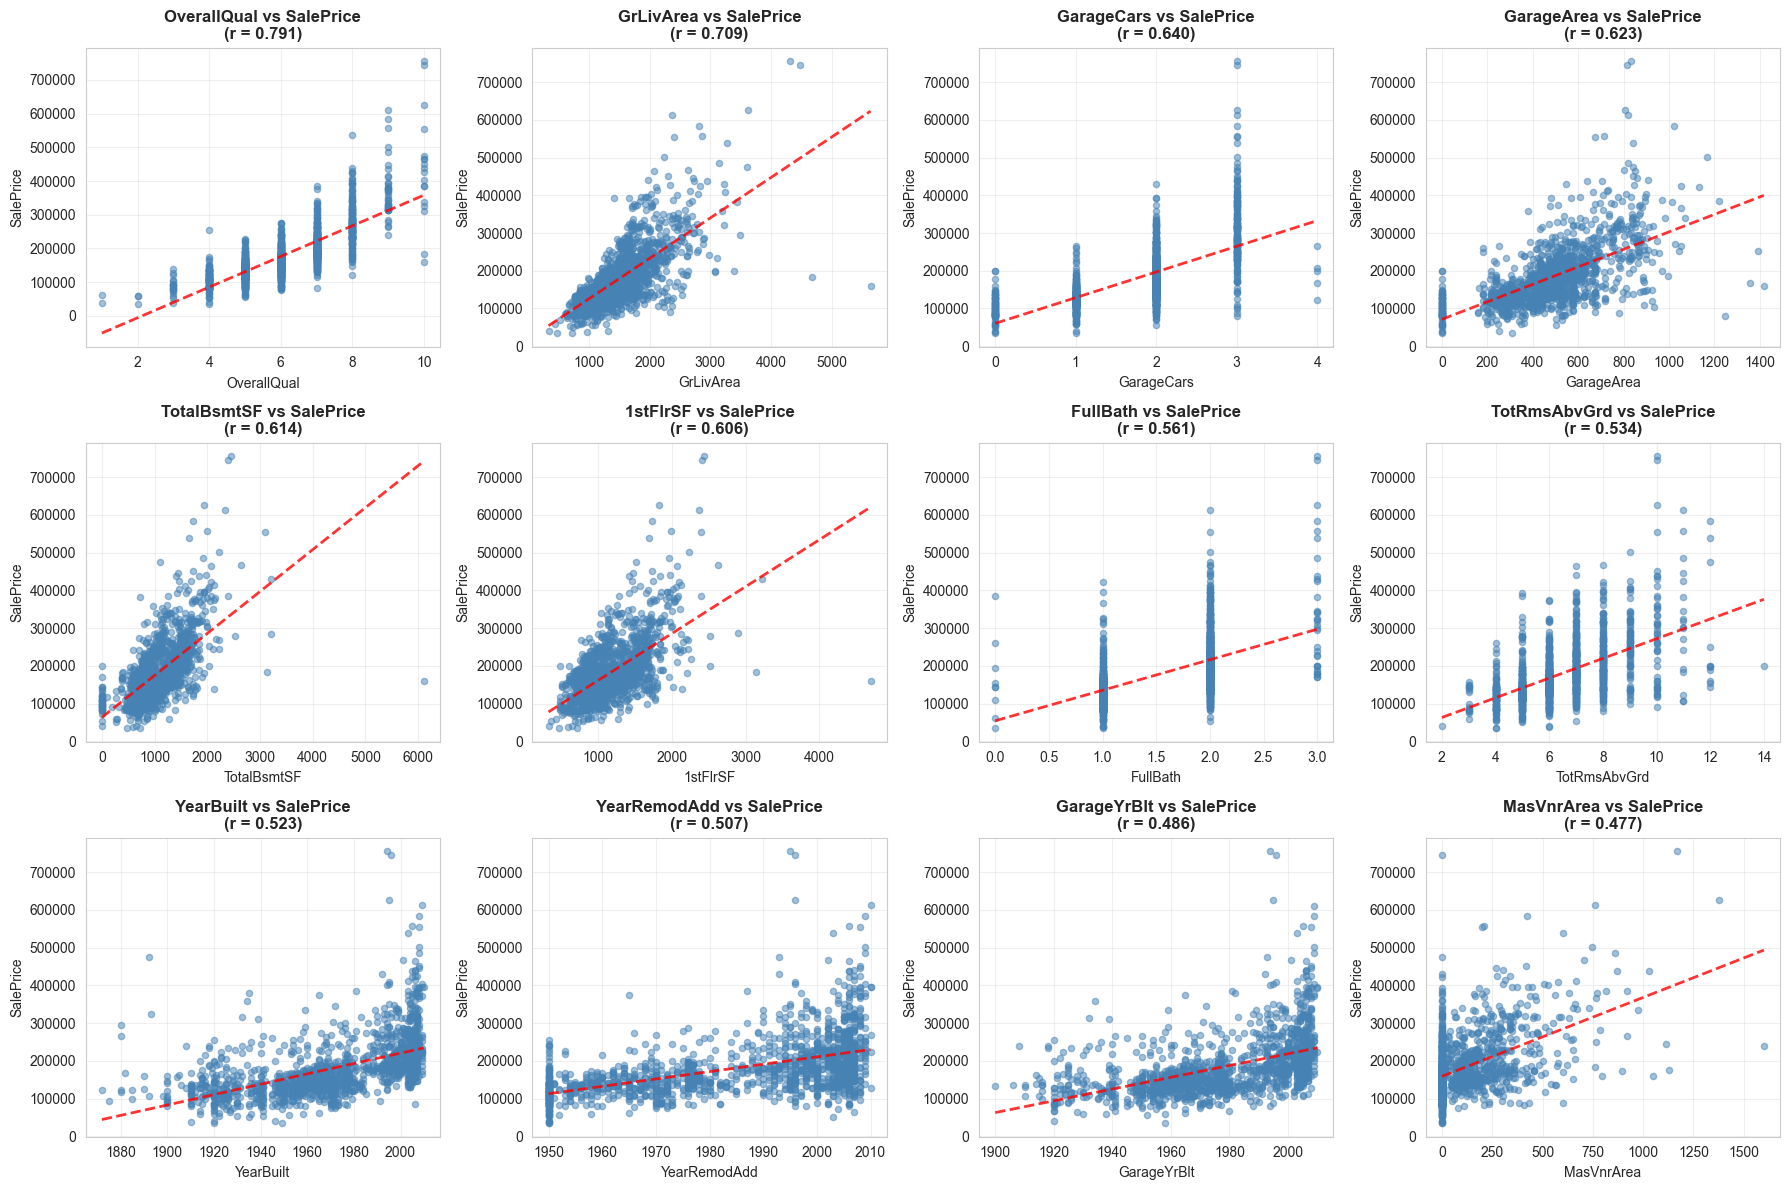

Relaciones entre las 12 variables con mayor correlación y SalePrice


In [21]:
# Seleccionar variables con correlación más fuerte con el target
top_features = correlations_with_target.drop(target).abs().nlargest(12).index.tolist()

# Crear scatter plots
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    axes[idx].scatter(df[feature], df[target], alpha=0.5, s=20, color='steelblue')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel(target)
    axes[idx].set_title(f'{feature} vs {target}\n(r = {correlation_matrix.loc[feature, target]:.3f})', fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Agregar línea de tendencia
    tmp = df[[feature, target]].dropna()
    z = np.polyfit(tmp[feature], tmp[target], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(tmp[feature].values)
    axes[idx].plot(x_sorted, p(x_sorted), "r--", linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()

print(f"Relaciones entre las 12 variables con mayor correlación y {target}")

## 5. Identificar Variables No Numéricas

Detectamos y catalogamos variables categóricas, ordinales o de texto, analizando su distribución de frecuencias y cardinalidad.

In [ ]:
# Análisis de variables categóricas
print("=" * 80)
print("ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("=" * 80)

for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Cardinalidad: {df[col].nunique()}")
    print(f"  Valores únicos: {df[col].unique()[:10]}")
    print(f"  Distribución de frecuencias:")
    print(df[col].value_counts().head(10))

ANÁLISIS DE VARIABLES CATEGÓRICAS

MSZoning:
  Cardinalidad: 5
  Valores únicos: ['RL' 'RM' 'C (all)' 'FV' 'RH']
  Distribución de frecuencias:
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Street:
  Cardinalidad: 2
  Valores únicos: ['Pave' 'Grvl']
  Distribución de frecuencias:
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

Alley:
  Cardinalidad: 2
  Valores únicos: [nan 'Grvl' 'Pave']
  Distribución de frecuencias:
Alley
Grvl    50
Pave    41
Name: count, dtype: int64

LotShape:
  Cardinalidad: 4
  Valores únicos: ['Reg' 'IR1' 'IR2' 'IR3']
  Distribución de frecuencias:
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

LandContour:
  Cardinalidad: 4
  Valores únicos: ['Lvl' 'Bnk' 'Low' 'HLS']
  Distribución de frecuencias:
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

Utilities:
  Cardinalidad: 2
  Valores únicos: ['AllPub' 'NoSeWa

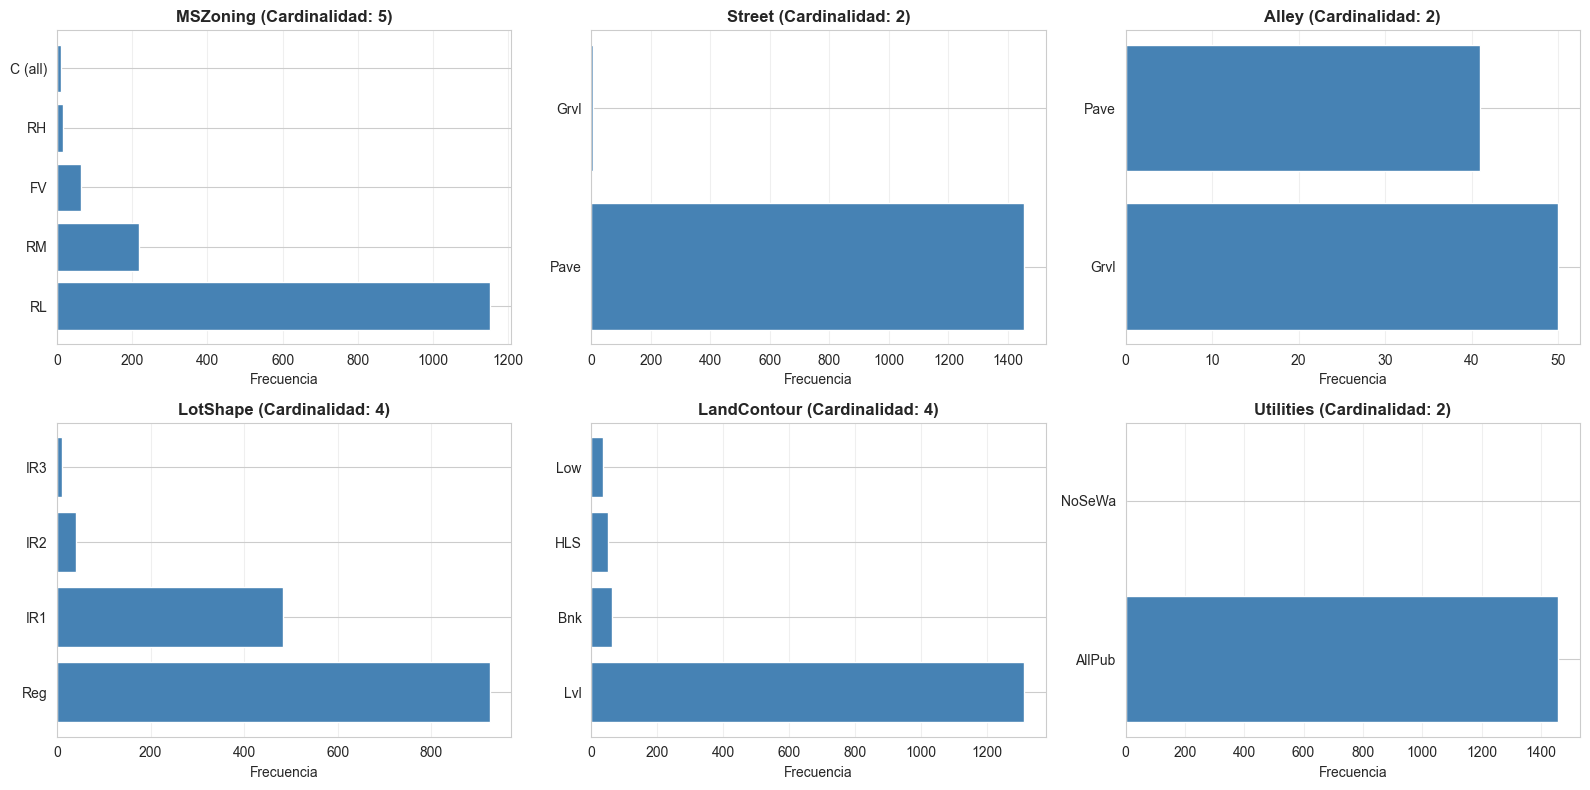

Distribuciones de variables categóricas (top 10 valores)


In [ ]:
# Visualizar distribuciones de variables categóricas
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols[:6]):
    top_values = df[col].value_counts().head(10)
    axes[idx].barh(range(len(top_values)), top_values.values, color='steelblue')
    axes[idx].set_yticks(range(len(top_values)))
    axes[idx].set_yticklabels(top_values.index)
    axes[idx].set_xlabel('Frecuencia')
    axes[idx].set_title(f'{col} (Cardinalidad: {df[col].nunique()})', fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Distribuciones de variables categóricas (top 10 valores)")

## 6. Transformaciones y Preparación de Datos

Definimos estrategias de transformación incluyendo encoding de variables categóricas, normalización/estandarización, tratamiento de outliers y manejo de valores faltantes.

In [ ]:
print("=" * 80)
print("PLAN DE TRANSFORMACIONES Y PREPARACIÓN DE DATOS")
print("=" * 80)

transformations = {
    'Variables Numéricas': {
        'acciones': [
            '1. Normalización/Estandarización: usar StandardScaler o MinMaxScaler',
            '2. Tratamiento de Outliers: identificar y manejo mediante IQR o Z-score',
            '3. Transformación de variables asimétricas: aplicar log, sqrt o Box-Cox',
            '4. Normalización de distribuciones: para variables con alta asimetría'
        ]
    },
    'Variables Categóricas': {
        'acciones': [
            '1. One-Hot Encoding: para variables nominales con baja cardinalidad (< 10)',
            '2. Label Encoding: para variables ordinales o de alta cardinalidad',
            '3. Target Encoding: codificar basándose en la media de la variable objetivo',
            '4. Agrupación: combinar categorías con baja frecuencia'
        ]
    },
    'Valores Faltantes': {
        'acciones': [
            '1. Variables numéricas: imputar con media, mediana o KNN',
            '2. Variables categóricas: imputar con moda o crear categoría "Missing"',
            '3. Filas con muchos valores faltantes: considerar eliminación'
        ]
    }
}

for category, details in transformations.items():
    print(f"\n{category}:")
    for action in details['acciones']:
        print(f"  {action}")

PLAN DE TRANSFORMACIONES Y PREPARACIÓN DE DATOS

Variables Numéricas:
  1. Normalización/Estandarización: usar StandardScaler o MinMaxScaler
  2. Tratamiento de Outliers: identificar y manejo mediante IQR o Z-score
  3. Transformación de variables asimétricas: aplicar log, sqrt o Box-Cox
  4. Normalización de distribuciones: para variables con alta asimetría

Variables Categóricas:
  1. One-Hot Encoding: para variables nominales con baja cardinalidad (< 10)
  2. Label Encoding: para variables ordinales o de alta cardinalidad
  3. Target Encoding: codificar basándose en la media de la variable objetivo
  4. Agrupación: combinar categorías con baja frecuencia

Valores Faltantes:
  1. Variables numéricas: imputar con media, mediana o KNN
  2. Variables categóricas: imputar con moda o crear categoría "Missing"
  3. Filas con muchos valores faltantes: considerar eliminación


In [23]:
# Análisis detallado de transformaciones necesarias
print("\n" + "=" * 80)
print("RECOMENDACIONES ESPECÍFICAS POR VARIABLE")
print("=" * 80)

recommendations = []

# Analizar variables numéricas
for col in numeric_cols:
    skewness = stats.skew(df[col].dropna())
    abs_skew = abs(skewness)
    
    transform_needed = "Sí" if abs_skew > 0.5 else "No"
    transform_type = ""
    
    if abs_skew > 1:
        transform_type = "Log o Box-Cox (fuerte asimetría)"
    elif abs_skew > 0.5:
        transform_type = "Sqrt o Log (asimetría moderada)"
    else:
        transform_type = "Sin transformación"
    
    recommendations.append({
        'Variable': col,
        'Tipo': 'Numérica',
        'Asimetría': round(skewness, 3),
        'Transformación': transform_type
    })

print("\nVariables numéricas con asimetría > 0.5 (candidatas a transformación):")
rec_df = pd.DataFrame(recommendations)
print(rec_df[rec_df['Asimetría'].abs() > 0.5].to_string(index=False))


RECOMENDACIONES ESPECÍFICAS POR VARIABLE

Variables numéricas con asimetría > 0.5 (candidatas a transformación):
     Variable     Tipo  Asimetría                   Transformación
   MSSubClass Numérica      1.406 Log o Box-Cox (fuerte asimetría)
  LotFrontage Numérica      2.161 Log o Box-Cox (fuerte asimetría)
      LotArea Numérica     12.195 Log o Box-Cox (fuerte asimetría)
  OverallCond Numérica      0.692  Sqrt o Log (asimetría moderada)
    YearBuilt Numérica     -0.613  Sqrt o Log (asimetría moderada)
 YearRemodAdd Numérica     -0.503  Sqrt o Log (asimetría moderada)
   MasVnrArea Numérica      2.666 Log o Box-Cox (fuerte asimetría)
   BsmtFinSF1 Numérica      1.684 Log o Box-Cox (fuerte asimetría)
   BsmtFinSF2 Numérica      4.251 Log o Box-Cox (fuerte asimetría)
    BsmtUnfSF Numérica      0.919  Sqrt o Log (asimetría moderada)
  TotalBsmtSF Numérica      1.523 Log o Box-Cox (fuerte asimetría)
     1stFlrSF Numérica      1.375 Log o Box-Cox (fuerte asimetría)
     2ndFlrSF N


EJEMPLO DE TRANSFORMACIONES DE VARIABLES ASIMÉTRICAS


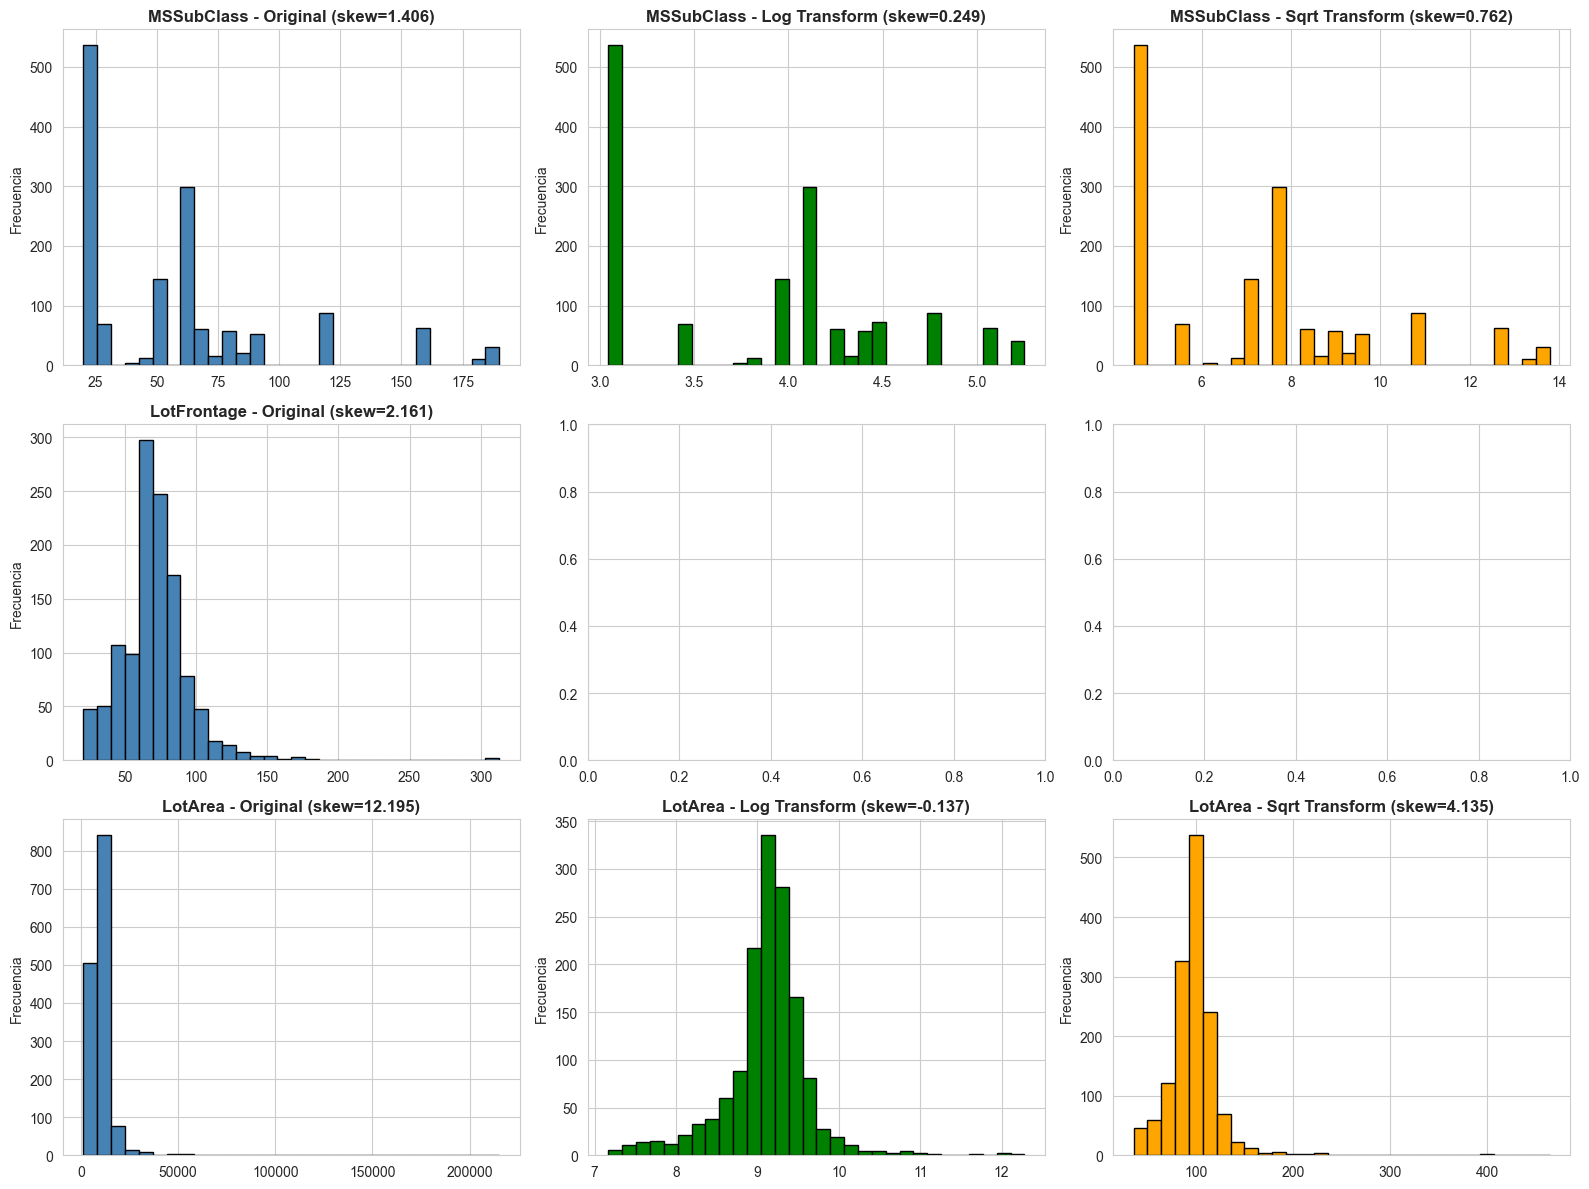

In [24]:
# Mostrar ejemplo de transformaciones
print("\n" + "=" * 80)
print("EJEMPLO DE TRANSFORMACIONES DE VARIABLES ASIMÉTRICAS")
print("=" * 80)

# Seleccionar variables con alta asimetría
high_skew_vars = rec_df[rec_df['Asimetría'].abs() > 1]['Variable'].tolist()[:3]

if len(high_skew_vars) > 0:
    fig, axes = plt.subplots(len(high_skew_vars), 3, figsize=(16, 4*len(high_skew_vars)))
    
    for row, var in enumerate(high_skew_vars):
        # Original
        axes[row, 0].hist(df[var].dropna(), bins=30, color='steelblue', edgecolor='black')
        axes[row, 0].set_title(f'{var} - Original (skew={stats.skew(df[var].dropna()):.3f})', fontweight='bold')
        axes[row, 0].set_ylabel('Frecuencia')
        
        # Log transformation
        if (df[var] > 0).all():
            log_var = np.log1p(df[var])
            axes[row, 1].hist(log_var.dropna(), bins=30, color='green', edgecolor='black')
            axes[row, 1].set_title(f'{var} - Log Transform (skew={stats.skew(log_var.dropna()):.3f})', fontweight='bold')
            axes[row, 1].set_ylabel('Frecuencia')
        
        # Sqrt transformation
        if (df[var] >= 0).all():
            sqrt_var = np.sqrt(df[var])
            axes[row, 2].hist(sqrt_var.dropna(), bins=30, color='orange', edgecolor='black')
            axes[row, 2].set_title(f'{var} - Sqrt Transform (skew={stats.skew(sqrt_var.dropna()):.3f})', fontweight='bold')
            axes[row, 2].set_ylabel('Frecuencia')
    
    plt.tight_layout()
    plt.show()
else:
    print("No hay variables con asimetría muy alta en este dataset")

## 7. Evaluación de Multicolinealidad

Calculamos el Variance Inflation Factor (VIF) para detectar variables altamente correlacionadas que puedan afectar la calidad del modelo.

In [25]:
# Calcular VIF para variables numéricas
print("=" * 80)
print("VARIANCE INFLATION FACTOR (VIF) - DETECCIÓN DE MULTICOLINEALIDAD")
print("=" * 80)

# Usar solo variables numéricas sin valores faltantes
numeric_clean = df[numeric_cols].dropna()

vif_data = pd.DataFrame({
    'Variable': numeric_clean.columns,
    'VIF': [variance_inflation_factor(numeric_clean.values, i) for i in range(numeric_clean.shape[1])]
})

vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data.to_string(index=False))

print("\nInterpretación de VIF:")
print("  VIF = 1: No hay correlación con otras variables")
print("  VIF < 5: Multicolinealidad aceptable")
print("  VIF > 5: Multicolinealidad problemática (considerar eliminar variable)")
print("  VIF > 10: Multicolinealidad severa (eliminar variable)")

VARIANCE INFLATION FACTOR (VIF) - DETECCIÓN DE MULTICOLINEALIDAD
     Variable          VIF
    GrLivArea          inf
     1stFlrSF          inf
   BsmtFinSF2          inf
    BsmtUnfSF          inf
  TotalBsmtSF          inf
   BsmtFinSF1          inf
 LowQualFinSF          inf
     2ndFlrSF          inf
  GarageYrBlt 26870.396001
       YrSold 25815.999173
    YearBuilt 24966.492508
 YearRemodAdd 24568.924102
 TotRmsAbvGrd    84.794130
  OverallQual    84.109917
  OverallCond    50.333753
 KitchenAbvGr    42.492097
   GarageCars    40.713992
   GarageArea    35.235024
 BedroomAbvGr    34.518898
    SalePrice    31.503370
     FullBath    28.831503
  LotFrontage    17.370124
       MoSold     6.842921
   MSSubClass     4.974705
           Id     4.124691
 BsmtFullBath     3.685412
     HalfBath     3.595159
      LotArea     3.496295
   Fireplaces     3.039296
   MasVnrArea     1.980613
  OpenPorchSF     1.965979
   WoodDeckSF     1.954010
EnclosedPorch     1.486878
  ScreenPorch    

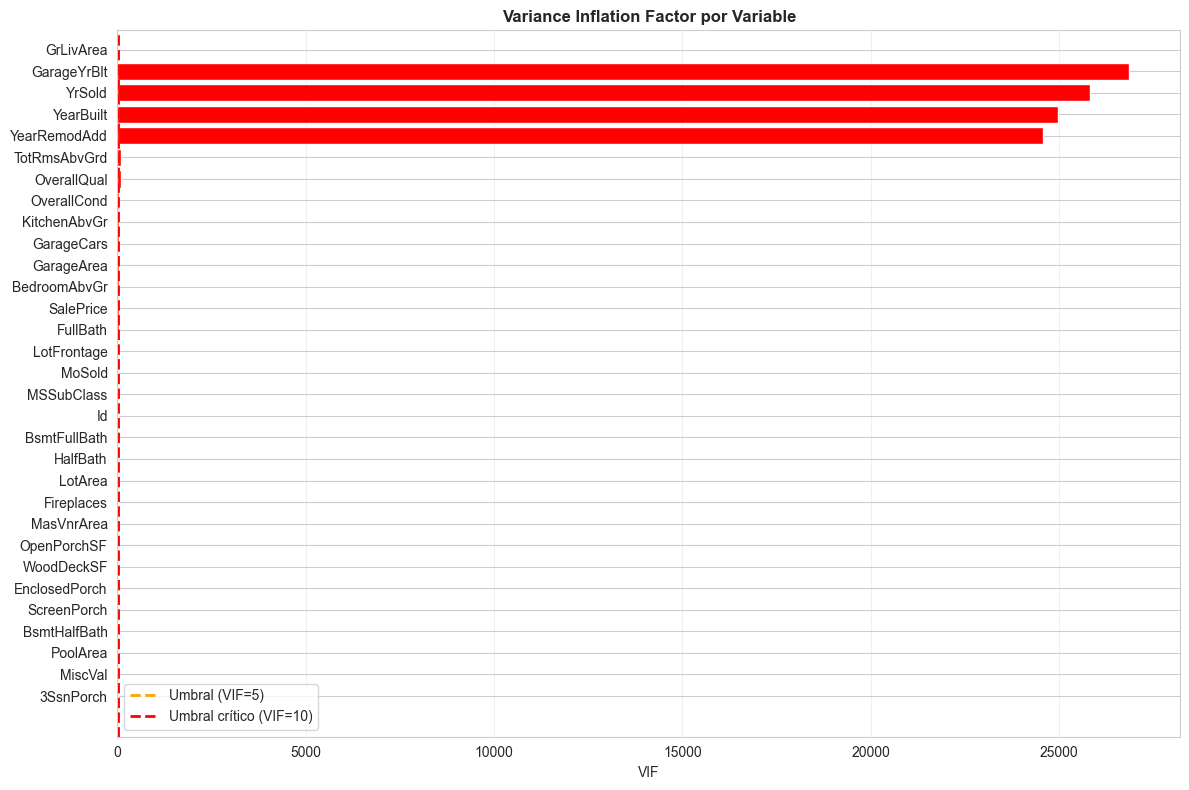

Variables con VIF > 5 (multicolinealidad problemática):
    Variable          VIF
   GrLivArea          inf
    1stFlrSF          inf
  BsmtFinSF2          inf
   BsmtUnfSF          inf
 TotalBsmtSF          inf
  BsmtFinSF1          inf
LowQualFinSF          inf
    2ndFlrSF          inf
 GarageYrBlt 26870.396001
      YrSold 25815.999173
   YearBuilt 24966.492508
YearRemodAdd 24568.924102
TotRmsAbvGrd    84.794130
 OverallQual    84.109917
 OverallCond    50.333753
KitchenAbvGr    42.492097
  GarageCars    40.713992
  GarageArea    35.235024
BedroomAbvGr    34.518898
   SalePrice    31.503370
    FullBath    28.831503
 LotFrontage    17.370124
      MoSold     6.842921


In [26]:
# Visualizar VIF
plt.figure(figsize=(12, 8))
vif_sorted = vif_data.sort_values('VIF', ascending=True)
plt.barh(vif_sorted['Variable'], vif_sorted['VIF'], color=['red' if x > 10 else 'orange' if x > 5 else 'green' for x in vif_sorted['VIF']])
plt.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='Umbral (VIF=5)')
plt.axvline(x=10, color='red', linestyle='--', linewidth=2, label='Umbral crítico (VIF=10)')
plt.xlabel('VIF')
plt.title('Variance Inflation Factor por Variable', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Variables con VIF > 5 (multicolinealidad problemática):")
high_vif = vif_data[vif_data['VIF'] > 5]
if len(high_vif) > 0:
    print(high_vif.to_string(index=False))
else:
    print("No hay variables con VIF > 5")

## 8. Resumen de Hallazgos y Próximos Pasos

Documentamos las observaciones clave sobre la capacidad predictiva de las variables, transformaciones necesarias y recomendaciones para la modelización.

In [27]:
print("=" * 80)
print("RESUMEN DE HALLAZGOS PRINCIPALES")
print("=" * 80)

summary = f"""
1. ESTRUCTURA DEL DATASET
   • Dimensiones: {df.shape[0]} muestras × {df.shape[1]} características
   • Variables numéricas: {len(numeric_cols)}
   • Variables categóricas: {len(categorical_cols)}
   • Valores faltantes: {df.isnull().sum().sum()} en total

2. VARIABLE DEPENDIENTE: {target}
   • Media: {df[target].mean():.2f}
   • Mediana: {df[target].median():.2f}
   • Desv. Est: {df[target].std():.2f}
   • Rango: [{df[target].min():.2f}, {df[target].max():.2f}]
   • Asimetría: {stats.skew(df[target].dropna()):.3f}

3. VARIABLES MÁS CORRELACIONADAS CON {target}
"""

print(summary)
for i, (var, corr) in enumerate(correlations_with_target.drop(target).head(5).items(), 1):
    print(f"   {i}. {var}: {corr:.3f}")

print(f"""
4. TRANSFORMACIONES REQUERIDAS
   • Variables con alta asimetría (|skew| > 1): {len(rec_df[rec_df['Asimetría'].abs() > 1])}
   • Variables a normalizar/estandarizar: Todas las numéricas
   • Variables categóricas a codificar: {len(categorical_cols)}
   • Variables con multicolinealidad (VIF > 5): {len(vif_data[vif_data['VIF'] > 5])}

5. PREPARACIÓN DE DATOS RECOMENDADA
   ✓ Imputar valores faltantes en variables numéricas con mediana
   ✓ Codificar variables categóricas (one-hot o label encoding según cardinalidad)
   ✓ Aplicar transformaciones log/sqrt a variables asimétricas
   ✓ Estandarizar variables numéricas (StandardScaler)
   ✓ Detectar y manejar outliers (IQR o Z-score)
   ✓ Considerar eliminar variables con VIF > 10

6. CAPACIDAD PREDICTIVA ESPERADA
   • Variables numéricas con correlación > 0.5: {len(correlations_with_target[(abs(correlations_with_target) > 0.5) & (correlations_with_target.index != target)])}
   • Relaciones lineales presentes: Sí, con variabilidad
   • Factores categóricos relevantes: Revisar mediante análisis de varianza
   • Posibilidad de extracción de P(y|X): MODERADA A BUENA
""")

print("=" * 80)
print("PRÓXIMOS PASOS RECOMENDADOS")
print("=" * 80)
print("""
1. Preparación de datos:
   ✓ Implementar pipeline de transformaciones
   ✓ Crear conjunto de entrenamiento y validación
   
2. Modelización:
   ✓ Probar modelos de regresión (Linear, Ridge, Lasso)
   ✓ Probar modelos de árbol (Decision Tree, Random Forest, XGBoost)
   ✓ Validar con validación cruzada
   
3. Evaluación:
   ✓ Usar métricas: MAE, RMSE, R²
   ✓ Analizar residuos
   ✓ Feature importance
   
4. Optimización:
   ✓ Ajuste de hiperparámetros
   ✓ Ingeniería de características adicionales
   ✓ Ensemble de modelos
""")

RESUMEN DE HALLAZGOS PRINCIPALES

1. ESTRUCTURA DEL DATASET
   • Dimensiones: 1460 muestras × 81 características
   • Variables numéricas: 38
   • Variables categóricas: 43
   • Valores faltantes: 7829 en total

2. VARIABLE DEPENDIENTE: SalePrice
   • Media: 180921.20
   • Mediana: 163000.00
   • Desv. Est: 79442.50
   • Rango: [34900.00, 755000.00]
   • Asimetría: 1.881

3. VARIABLES MÁS CORRELACIONADAS CON SalePrice

   1. OverallQual: 0.791
   2. GrLivArea: 0.709
   3. GarageCars: 0.640
   4. GarageArea: 0.623
   5. TotalBsmtSF: 0.614

4. TRANSFORMACIONES REQUERIDAS
   • Variables con alta asimetría (|skew| > 1): 20
   • Variables a normalizar/estandarizar: Todas las numéricas
   • Variables categóricas a codificar: 43
   • Variables con multicolinealidad (VIF > 5): 23

5. PREPARACIÓN DE DATOS RECOMENDADA
   ✓ Imputar valores faltantes en variables numéricas con mediana
   ✓ Codificar variables categóricas (one-hot o label encoding según cardinalidad)
   ✓ Aplicar transformaciones l

In [ ]:
# Crear tabla de resumen final
print("\n" + "=" * 80)
print("TABLA RESUMEN DE VARIABLES")
print("=" * 80)

summary_table = pd.DataFrame({
    'Variable': numeric_cols,
    'Tipo': 'Numérica',
    'Valores_Faltantes': [df[col].isnull().sum() for col in numeric_cols],
    'Correlación_Target': [correlation_matrix.loc[col, target] if col != target else 1.0 for col in numeric_cols],
    'Asimetría': [stats.skew(df[col].dropna()) for col in numeric_cols],
    'VIF': [vif_data[vif_data['Variable'] == col]['VIF'].values[0] if col in vif_data['Variable'].values else np.nan for col in numeric_cols]
})

summary_table = summary_table.sort_values('Correlación_Target', ascending=False, key=abs)
print(summary_table.to_string(index=False))


TABLA RESUMEN DE VARIABLES
     Variable     Tipo  Valores_Faltantes  Correlación_Target  Asimetría          VIF
    SalePrice Numérica                  0            1.000000   1.880941    31.503370
  OverallQual Numérica                  0            0.790982   0.216721    84.109917
    GrLivArea Numérica                  0            0.708624   1.365156          inf
   GarageCars Numérica                  0            0.640409  -0.342197    40.713992
   GarageArea Numérica                  0            0.623431   0.179796    35.235024
  TotalBsmtSF Numérica                  0            0.613581   1.522688          inf
     1stFlrSF Numérica                  0            0.605852   1.375342          inf
     FullBath Numérica                  0            0.560664   0.036524    28.831503
 TotRmsAbvGrd Numérica                  0            0.533723   0.675646    84.794130
    YearBuilt Numérica                  0            0.522897  -0.612831 24966.492508
 YearRemodAdd Numérica    

In [ ]:
# Crear tabla de resumen final
print("\n" + "=" * 80)
print("TABLA RESUMEN DE VARIABLES")
print("=" * 80)

summary_table = pd.DataFrame({
    'Variable': numeric_cols,
    'Tipo': 'Numérica',
    'Valores_Faltantes': [df[col].isnull().sum() for col in numeric_cols],
    'Correlación_Target': [correlation_matrix.loc[col, target] if col != target else 1.0 for col in numeric_cols],
    'Asimetría': [stats.skew(df[col].dropna()) for col in numeric_cols],
    'VIF': [vif_data[vif_data['Variable'] == col]['VIF'].values[0] if col in vif_data['Variable'].values else np.nan for col in numeric_cols]
})

summary_table = summary_table.sort_values('Correlación_Target', ascending=False, key=abs)
print(summary_table.to_string(index=False))


TABLA RESUMEN DE VARIABLES
     Variable     Tipo  Valores_Faltantes  Correlación_Target  Asimetría          VIF
    SalePrice Numérica                  0            1.000000   1.880941    31.503370
  OverallQual Numérica                  0            0.790982   0.216721    84.109917
    GrLivArea Numérica                  0            0.708624   1.365156          inf
   GarageCars Numérica                  0            0.640409  -0.342197    40.713992
   GarageArea Numérica                  0            0.623431   0.179796    35.235024
  TotalBsmtSF Numérica                  0            0.613581   1.522688          inf
     1stFlrSF Numérica                  0            0.605852   1.375342          inf
     FullBath Numérica                  0            0.560664   0.036524    28.831503
 TotRmsAbvGrd Numérica                  0            0.533723   0.675646    84.794130
    YearBuilt Numérica                  0            0.522897  -0.612831 24966.492508
 YearRemodAdd Numérica    